In [1]:
### Make notebook wider:

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

In [2]:
# ## setup structrue for later

# out_df = pd.DataFrame(
#     {'animal' : [],
#     'trials_at_start' : [],
#     'std1' : [],
#      'std2':[],
#     'std3' : [],
#     'std4' : []})

In [2]:
import os
import pandas as pd
from pathlib import Path, PurePosixPath
import numpy as np
import matplotlib.pyplot as plt

def load_H5_bodypart_ports(tracking_path):

    back_file = pd.read_hdf(tracking_file)

    # drag data out of the df
    scorer = back_file.columns.tolist()[0][0]
    headcentre = back_file[scorer].headcentre

    # clean and interpolate frames with less than 98% confidence
    clean_and_interpolate(headcentre,0.98)

    port1 =back_file[scorer]['port1']
    port2 =back_file[scorer]['port2']
    port3 =back_file[scorer]['port3']
    port4 =back_file[scorer]['port4']
    port5 =back_file[scorer]['port5']

    clean_and_interpolate(port1,0.9)
    clean_and_interpolate(port2,0.9)
    clean_and_interpolate(port3,0.9)
    clean_and_interpolate(port4,0.9)
    clean_and_interpolate(port5,0.9)

    return headcentre,port1,port2,port3,port4,port5


def list_files(directory, extension):
    return (f for f in os.listdir(directory) if f.endswith('.' + extension))

def files(folderpath, pattern="*"):
    """
        returns all files folders in a given folder matching a pattern
    """
    return [f for f in folderpath.glob(pattern) if f.is_file()]

def clean_and_interpolate(head_centre,threshold):
    bad_confidence_inds = np.where(head_centre.likelihood.values<threshold)[0]
    newx = head_centre.x.values
    newx[bad_confidence_inds] = 0
    newy = head_centre.y.values
    newy[bad_confidence_inds] = 0

    start_value_cleanup(newx)
    interped_x = interp_0_coords(newx)

    start_value_cleanup(newy)
    interped_y = interp_0_coords(newy)
    
    head_centre['interped_x'] = interped_x
    head_centre['interped_y'] = interped_y
    
def start_value_cleanup(coords):
    # This is for when the starting value of the coords == 0; interpolation will not work on these coords until the first 0 
    #is changed. The 0 value is changed to the first non-zero value in the coords lists
    for index, value in enumerate(coords):
        working = 0
        if value > 0:
            start_value = value
            start_index = index
            working = 1
            break
    if working == 1:
        for x in range(start_index):
            coords[x] = start_value
            
def interp_0_coords(coords_list):
    #coords_list is one if the outputs of the get_x_y_data = a list of co-ordinate points
    for index, value in enumerate(coords_list):
        if value == 0:
            if coords_list[index-1] > 0:
                value_before = coords_list[index-1]
                interp_start_index = index-1
                #print('interp_start_index: ', interp_start_index)
                #print('interp_start_value: ', value_before)
                #print('')

        if index < len(coords_list)-1:
            if value ==0:
                if coords_list[index+1] > 0:
                    interp_end_index = index+1
                    value_after = coords_list[index+1]
                    #print('interp_end_index: ', interp_end_index)
                    #print('interp_end_value: ', value_after)
                    #print('')

                    #now code to interpolate over the values
                    try:
                        interp_diff_index = interp_end_index - interp_start_index
                    except UnboundLocalError:
#                         print('the first value in list is 0, use the function start_value_cleanup to fix')
                        break
                    #print('interp_diff_index is:', interp_diff_index)

                    new_values = np.linspace(value_before, value_after, interp_diff_index)
                    #print(new_values)

                    interp_index = interp_start_index+1
                    for x in range(interp_diff_index):
                        #print('interp_index is:', interp_index)
                        #print('new_value should be:', new_values[x])
                        coords_list[interp_index] = new_values[x]
                        interp_index +=1
        if index == len(coords_list)-1:
            if value ==0:
                for x in range(30):
                    coords_list[index-x] = coords_list[index-30]
                    #print('')
#     print('function exiting')
    return(coords_list)

In [3]:
path = r"Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\\"

tracking_info_df= pd.read_csv(r"Z:\projects\Emmett\tracking_analysis\training_tracking\tracking_df.csv")


tracking_files = []
animals = []
sessions = []
for animal in os.listdir(path):
    folders = os.listdir(path + animal)
    for index,folder in enumerate(folders):
        current_tracking_path = os.path.join(path + animal,folder) + '\\'
        if len(os.listdir(current_tracking_path)) > 0:
    
            tracking_files__ = files(Path(current_tracking_path), "*.h5")
            for file in tracking_files__:
                tracking_files.append(os.path.join(current_tracking_path,file))
                animals += [animal]
                sessions +=[folder]
                
# make dataframe:
tracking_df = pd.DataFrame(
    {'animal' : animals,
     'session':sessions,
     'trials_at_start': tracking_info_df.trial_start[0:len(animals)].values,
    'tracking_files' : tracking_files})

In [823]:
back_tracking = []
port_tracking = []
for tracking_file in tracking_df.tracking_files:
    print(tracking_file)
    if 'Normal' in tracking_file:
        back_head_centre,p1,p2,p3,p4,p5 = load_H5_bodypart_ports(tracking_file)
        back_tracking.append(back_head_centre)
        port_tracking.append([p1,p2,p3,p4,p5])


tracking_df['back_tracking'] = back_tracking
# tracking_df['port_tracking'] = port_tracking

Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\EJT27\Session20\EJT272020-01-30T14_30_20DLC_resnet50_Normal_tracking_back_and_portsApr25shuffle1_800000.h5
Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\EJT27\Session29\EJT272020-02-11T13_22_40DLC_resnet50_Normal_tracking_back_and_portsApr25shuffle1_800000.h5
Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\EJT27\Sesssion9\EJT27EarlyTrainingVideo2020-01-15T14_17_55DLC_resnet50_Normal_tracking_back_and_portsApr25shuffle1_800000.h5
Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\EJT29\Session10\EarlyTrainingEJT29video2020-01-15T14_34_21DLC_resnet50_Normal_tracking_back_and_portsApr25shuffle1_800000.h5
Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\EJT29\Session19\EJT292020-01-30T13_28_24DLC_resnet50_Normal_tracking_back_and_portsApr25shuffle1_800000.h5
Z:\projects\Emmett\tracking_analysis\training_tracking\tracking\EJT29\Session37\EJT292020-03-02T12_35_39DLC_r

In [824]:
### EJT30 is a good example of change over trials. 

In [825]:
tracking_df

,animal,session,trials_at_start,tracking_files,back_tracking
0,EJT27,Session20,3904,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
1,EJT27,Session29,6604,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
2,EJT27,Sesssion9,1005,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
3,EJT29,Session10,846,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
4,EJT29,Session19,3006,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
5,EJT29,Session37,8435,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
6,EJT29,Session49,13022,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
7,EJT30,Session37,7822,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
8,EJT30,Session49,12113,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
9,EJT30,Session9,1584,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...


In [597]:
def closest_points(target, points, threshold):
    import math
    closest = []
    indicies = []
    for index,point in enumerate(points):
        distance = math.dist(target,point)
        if distance <= threshold:
            closest.append(point)
            indicies.append(index)
    return closest,indicies


def find_next_val(index,threshold_breaks,frame_filter,port_type):
    p2_indicies = np.where(threshold_breaks == port_type)[0]
    try:
        p2_min_val = min(i for i in p2_indicies if i > index)
        distance = p2_min_val - index
    except:
        distance = 9999999
    if distance<frame_filter:
        return p2_min_val
    else:
        return -1

In [1342]:
### loop over this and plot out stuff
animal = 9

current_x = tracking_df.back_tracking[animal].interped_x.values
current_y = tracking_df.back_tracking[animal].interped_y.values
port_positions = []
for i in range(5):
    port = port_tracking[animal][i]
    if animal == 2 and i == 1:
        # hacky fix because port 1 was messed up for this tracking
        port_positions += [[np.median(port_tracking[animal][3].interped_x.values),np.median(port_tracking[animal][0].interped_y.values)]]
    else:
        port_positions += [[np.median(port.interped_x),np.median(port.interped_y)]]
    
port_centroids = port_positions
    
coords = []
for ind_,item in enumerate(current_x):
    coords += [[item,current_y[ind_]]]

radius = 45
threshold_breaks = np.zeros(len(coords))
# for each port we care about find where the mouse breaks the distcance threshold
for ind_ in range(0,len(port_centroids)):
    threshold = radius
    target = port_centroids[ind_]
    closest,indicies = closest_points(target, coords, threshold)
    
    threshold_breaks[indicies] = ind_ + 1

# exclude (by labelling with -1) any times the trajetcory goes outside of the port area
half_dist = (port_centroids[0][-1] - port_centroids[4][-1])/2
exclusion_mask = (np.array(current_y) < (port_centroids[0][-1] + half_dist)) * (np.array(current_y) > (port_centroids[4][-1] - half_dist))
exclusion_inds = np.where(exclusion_mask == False)
threshold_breaks[exclusion_inds] = -1

# exclude (by labelling with -1) any times the trajetcory goes outside of the port area
half_dist = (port_centroids[1][0] - port_centroids[0][0])/2
exclusion_mask = (np.array(current_x) > (port_centroids[0][0] - half_dist)) * (np.array(current_x) < (port_centroids[4][0] + half_dist))
exclusion_inds = np.where(exclusion_mask == False)
threshold_breaks[exclusion_inds] = -1

## each of these is a frame so we know the timing between them. ie. one frame is 1/60s 
time_filter = 2 #in s
frame_filter = int(time_filter / (1/60))

In [1343]:
def extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,exclude_port_1,exclude_port_2,exclude_port_3):

    start_ind = []
    end_ind = []


    index = 0
    while index < len(threshold_breaks[:-1]):
        break_ = threshold_breaks[index]
        if break_ == start_port and not threshold_breaks[index+1] ==start_port:
            # find min valin this that is larger than current - ie. next index
            p3_ind = find_next_val(index,threshold_breaks,frame_filter,end_port)
            # ignore any really bad ones that enter othe rports first, the -1 takes care of the excluded trajectories (gets rid of weird noise hwere the DLC tracking jumps outsid eof the task zone)
            if not exclude_port_1 in threshold_breaks[index:p3_ind] and not exclude_port_2 in threshold_breaks[index:p3_ind] and not exclude_port_3 in threshold_breaks[index:p3_ind] and not -1 in threshold_breaks[index:p3_ind]:
                if p3_ind != -1:
                    start_ind += [index-3]
                    end_ind += [p3_ind+3]
                    if not index == (p3_ind - 1):
                        index = p3_ind - 1
                    else:
                        index = p3_ind
                else:
                    index+=1
            else:
                index += 1
        else:
            index +=1

    return start_ind, end_ind

In [1344]:
## each of these is a frame so we know the timing between them. ie. one frame is 1/60s 
time_filter = 1.5 #in s
frame_filter = int(time_filter / (1/60))


start_port = 5
end_port = 1
# T1_start_ind, T1_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,3,3,4)
T1_start_ind, T1_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,3,4,-1)

start_port = 1
end_port = 4
T2_start_ind, T2_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,-1,3,5)


start_port = 4
end_port = 3
T3_start_ind, T3_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,2,5)

start_port = 3
end_port = 5
T4_start_ind, T4_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,-1,4)


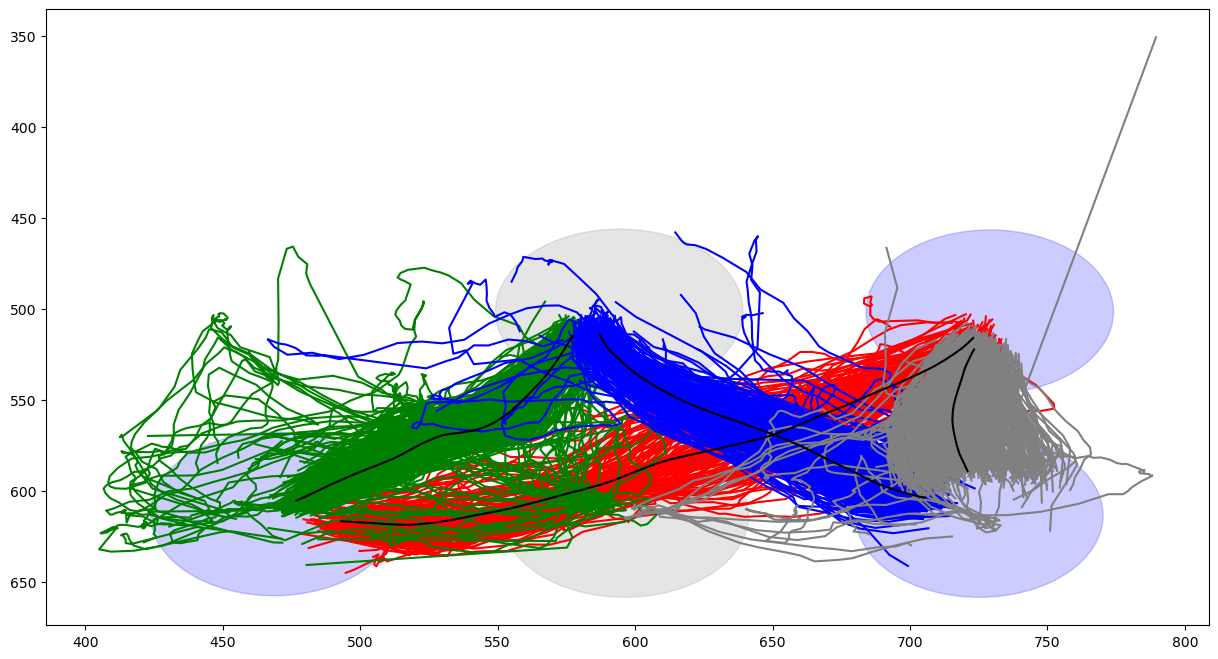

In [1345]:
def plot_and_create_xy_segments(T1_start_ind,T1_end_ind,ax,col):
    segment1 = []
    for i in range(len(T1_start_ind)):
        ax.plot(current_x[T1_start_ind[i]:T1_end_ind[i]],current_y[T1_start_ind[i]:T1_end_ind[i]],'-', color = col, alpha = 1)    
        x_vals = current_x[T1_start_ind[i]:T1_end_ind[i]]
        y_vals = current_y[T1_start_ind[i]:T1_end_ind[i]]
        xy_coords = []
        for index,x in enumerate(x_vals):
            xy_coords += [(x,y_vals[index])]
        segment1 += [xy_coords]
    return(segment1)

from scipy.interpolate import interp1d

def interpolate_to_longest_and_find_average_curve(curves):
    
    

    # Find the length of the longest curve
    max_length = max([len(curve) for curve in curves])

    # Interpolate each curve to the length of the longest curve
    interpolated_curves = []
    for curve in curves:
        if len(curve) > 0:
            x = [point[0] for point in curve]
            y = [point[1] for point in curve]

            # find lots of points on the piecewise linear curve defined by x and y
            M = max_length
            t = np.linspace(0, len(x), M)
            x_interp = np.interp(t, np.arange(len(x)), x)
            y_interp = np.interp(t, np.arange(len(y)), y)

            interpolated_curves.append([[x, y] for x, y in zip(x_interp, y_interp)])

    # # Average the x and y coordinates of all the interpolated curves
    average_curve = []
    for i in range(max_length):
        x_sum = 0
        y_sum = 0
        for curve in interpolated_curves:
            x_sum += curve[i][0]
            y_sum += curve[i][1]
        average_curve.append([x_sum / len(interpolated_curves), y_sum / len(interpolated_curves)])

    return average_curve

    

filtered_split_trajectories_x_positions = []
filtered_split_trajectories_y_positions = []
filtered_split_trajectories_frame_colors = []

# plot these filtered trajectories:

nrow = 1 
ncol = 1
fig, axs = plt.subplots(nrow, ncol,figsize=(15, 8))

for ind, ax in enumerate(fig.axes):
    
    for index,port_centroid in enumerate(port_centroids):
        ## define rings around important ports: port 5, port2, port 3, port4
        radius = 45
        c = ['blue','grey','blue','grey','blue']
        circle1 = plt.Circle(port_centroid, radius, color=c[index], alpha = 0.2)
        ax.add_patch(circle1)

segment1 = plot_and_create_xy_segments(T1_start_ind,T1_end_ind,ax,'red')
segment2 = plot_and_create_xy_segments(T2_start_ind,T2_end_ind,ax,'green')
segment3 = plot_and_create_xy_segments(T3_start_ind,T3_end_ind,ax,'blue')
segment4 = plot_and_create_xy_segments(T4_start_ind,T4_end_ind,ax,'grey')

a_curve1 = interpolate_to_longest_and_find_average_curve(segment1)
a_curve2 = interpolate_to_longest_and_find_average_curve(segment2)
a_curve3 = interpolate_to_longest_and_find_average_curve(segment3)
a_curve4 = interpolate_to_longest_and_find_average_curve(segment4)


x = [point[0] for point in a_curve1]
y = [point[1] for point in a_curve1]
ax.plot(x, y, '-', color ='black',alpha = 1)

x = [point[0] for point in a_curve2]
y = [point[1] for point in a_curve2]
ax.plot(x, y, '-', color ='black',alpha = 1)

x = [point[0] for point in a_curve3]
y = [point[1] for point in a_curve3]
ax.plot(x, y, '-', color ='black',alpha = 1)

x = [point[0] for point in a_curve4]
y = [point[1] for point in a_curve4]
ax.plot(x, y, '-', color ='black',alpha = 1)

ax.invert_yaxis()

In [1340]:
import numpy as np
from tqdm import tqdm
import math
from scipy.spatial import KDTree

def closest_point(line1, line2):
    tree = KDTree(line2)
    dist, index = tree.query(line1)
    return index, dist



def find_closest_point(target, points):
    import math
    min_distance = float('inf')
    closest_point = None
    closest_index = None
    for index, point in enumerate(points):
        distance = math.dist(target,point)
        if distance < min_distance:
            min_distance = distance
            closest_point = point
            closest_index = index
    return closest_point,closest_index

def find_closest_points(traject_coords,port_centroids):
    
    split_trajects_port_points = []
    split_trajects_port_indicies = []

    closest_points = []
    closest_inds = []
    for ind_,centroids in enumerate(port_centroids[1::]):
        # skip 0 ^see above and skip port 3: 
        if not centroids == port_centroids[2]:
            if not centroids == port_centroids[-1]:
                if ind_ ==  0:
                    # find closest to port 2
                    closest_point, closest_index = find_closest_point(centroids,traject_coords)
                    closest_points += [closest_point]
                    closest_inds += [closest_index]
                else:
                    #find closest to port 4 (from after port 2 onwards)
                    closest_point, closest_index = find_closest_point(centroids,traject_coords[closest_inds[-1]::])
                    closest_points += [closest_point]
                    closest_inds += [closest_index + closest_inds[-1]]
            else:
                # if port 5 search from port 4 onwards
                closest_point, closest_index = find_closest_point(centroids,traject_coords[closest_inds[-1]::])
                closest_points += [closest_point]
                closest_inds += [closest_index + closest_inds[-1]]

    ###make it so that point closest to port 1 can only be between port 5 and 2! 
    closest_point_1, closest_index_1 = find_closest_point(port_centroids[0],traject_coords[0:closest_inds[0]])

    ###make it so that point closest to port 3 can only be between port 2 and 4! 
    closest_point_3, closest_index_3 = find_closest_point(port_centroids[2],traject_coords[closest_inds[0]:closest_inds[1]])
    # this finds relative ind so I need to add on the offst from the start of the full traject
    closest_index_3 = closest_index_3 + closest_inds[0]

    split_trajects_port_points += [[closest_point_1] + [closest_points[0]] + [closest_point_3] + closest_points[1::]]
    split_trajects_port_indicies += [[closest_index_1] + [closest_inds[0]] + [closest_index_3] + closest_inds[1::]]
    
    return split_trajects_port_points, split_trajects_port_indicies

def total_length_of_curve(curve):
    x = [point[0] for point in curve]
    y = [point[1] for point in curve]
    dists = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    return np.sum(dists)

100%|████████████████████████████████████████████████████████████████████████████████| 82/82 [00:00<00:00, 6218.05it/s]


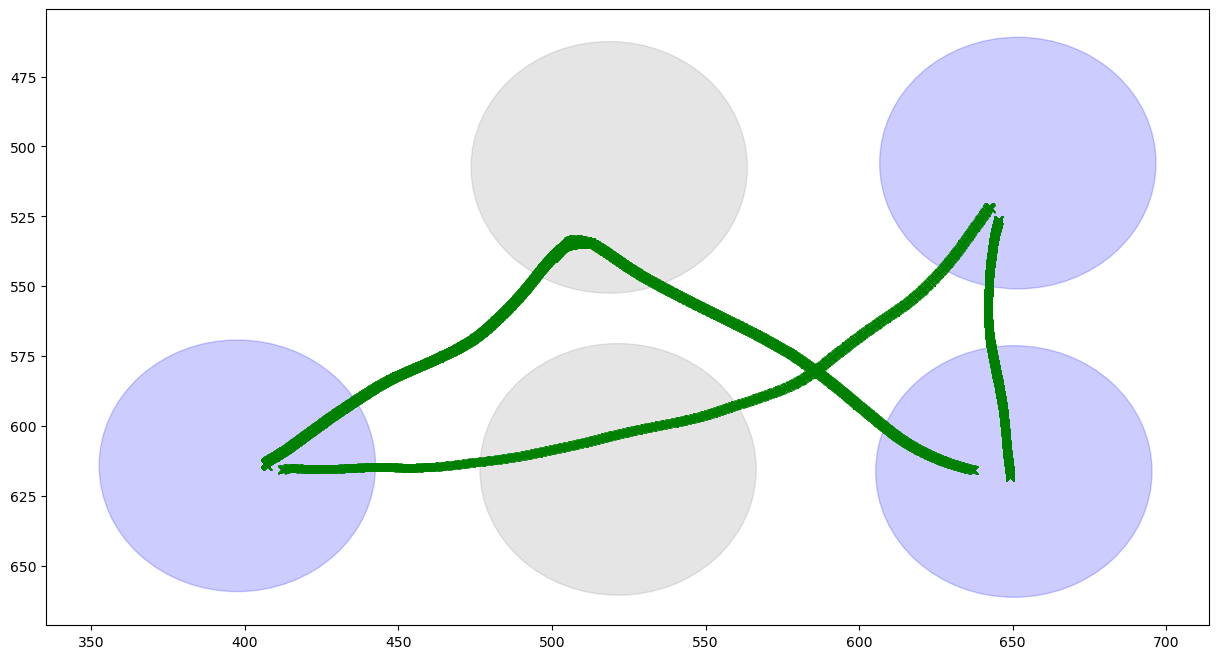

In [1341]:
interpolated_av_curves = []

for a_curve_ in [a_curve1,a_curve2,a_curve3,a_curve4]:

    total_length = total_length_of_curve(a_curve_)
    # chose number of points you want to construct the curve out of - this will only be roughly fitted as the code does a lot of rounding. This cant be smaller than the current length - ifyou do this is will just keep the curve the same (it can only add points)
    num_points = 2000
    # number to multiply the segment length to get the rough breakdown so that we get around 1000 in total 
    segment_warp_factor = num_points/int(total_length) 


    interpolated_av_curve = []
    for i in tqdm(range(len(a_curve_))):
        if i>0:
            st_ = a_curve_[i]
            ed_ = a_curve_[i-1]
            seg_distance = math.dist(st_,ed_)
            num_points_to_add = np.round(seg_distance * segment_warp_factor)
            if num_points_to_add >1:

                seg = [st_] + [ed_]
                x = [point[0] for point in seg]
                y = [point[1] for point in seg]

                M = int(num_points_to_add)
                t = np.linspace(0, len(x), M)
                x_interp = np.interp(t, np.arange(len(x)), x)
                y_interp = np.interp(t, np.arange(len(y)), y)

                interpolated_av_curve += ([[x, y] for x, y in zip(x_interp, y_interp)])


            else:
                interpolated_av_curve += [a_curve_[i]]
                
                
    interpolated_av_curves += [interpolated_av_curve]

            
nrow = 1 
ncol = 1
fig, axs = plt.subplots(nrow, ncol,figsize=(15, 8))

for ind, ax in enumerate(fig.axes):
    
    for index,port_centroid in enumerate(port_centroids):
        ## define rings around important ports: port 5, port2, port 3, port4
        radius = 45
        c = ['blue','grey','blue','grey','blue']
        circle1 = plt.Circle(port_centroid, radius, color=c[index], alpha = 0.2)
        ax.add_patch(circle1)
        
    ax.invert_yaxis()

    for interpolated_av_curve in interpolated_av_curves:
        x = [point[0] for point in interpolated_av_curve]
        y = [point[1] for point in interpolated_av_curve]
        ax.plot(x, y, 'x',color = 'green')
    




In [1164]:
median_dists1=[]
std_dists1 = []
for i in range(len(segment1)):
    index,dist = closest_point(segment1[i],interpolated_av_curves[0])
    median_dists1 += [np.median(dist)]
    std_dists1 += [np.std(dist)]


median_dists2=[]
std_dists2 = []
for i in range(len(segment2)):
    index,dist = closest_point(segment2[i],interpolated_av_curves[1])
    median_dists2 += [np.median(dist)]
    std_dists2 += [np.std(dist)]


median_dists3=[]
std_dists3 = []
for i in range(len(segment3)):
    index,dist = closest_point(segment3[i],interpolated_av_curves[2])
    median_dists3 += [np.median(dist)]
    std_dists3 += [np.std(dist)]


median_dists4=[]
std_dists4 = []
for i in range(len(segment4)):
    index,dist = closest_point(segment4[i],interpolated_av_curves[3])
    median_dists4 += [np.median(dist)]
    std_dists4 += [np.std(dist)]


In [1165]:

animal_name = tracking_df.animal[animal]
trials_at_start = tracking_df.trials_at_start[animal]


df = pd.DataFrame(
    {'animal' : [animal_name],
    'trials_at_start' : [trials_at_start],
    'std1' : [np.mean(std_dists1)],
     'std2':[np.mean(std_dists2)],
    'std3' : [np.mean(std_dists3)],
    'std4' : [np.mean(std_dists4)]})

df

,animal,trials_at_start,std1,std2,std3,std4
0,EJT52,1826,3.458868,3.785016,2.420664,2.576267


In [1166]:
np.mean([df.std1.values[0],df.std2.values[0],df.std3.values[0],df.std4.values[0]])

3.060203568451739

In [1132]:
np.mean([out_df.std1.values[animal],out_df.std2.values[animal],out_df.std3.values[animal],out_df.std4.values[animal]])

IndexError: index 44 is out of bounds for axis 0 with size 41

# ---------------------------------------------------------------------------------------------------------

In [1133]:
### if happy then save this out for that seq:

animal_name = tracking_df.animal[animal]
trials_at_start = tracking_df.trials_at_start[animal]

df = pd.DataFrame(
    {'animal' : [animal_name],
    'trials_at_start' : [trials_at_start],
    'std1' : [np.mean(std_dists1)],
     'std2':[np.mean(std_dists2)],
    'std3' : [np.mean(std_dists3)],
    'std4' : [np.mean(std_dists4)]})

out_df = out_df.append(df)

C:\Users\Emmett\AppData\Local\Temp\ipykernel_30428\3830786522.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  out_df = out_df.append(df)


# __________________________________________________________________________________

In [1134]:
# ## save out the data 
# out_df.reset_index(drop=True, inplace=True)

# out_df.to_csv(r"Z:\projects\Emmett\tracking_analysis\training_tracking\all_extracted_standard_deviations.csv")


In [1705]:
def SaveFig(file_name,figure_dir):
    if not os.path.isdir(figure_dir):
        os.makedirs(figure_dir)
    plt.savefig(figure_dir + file_name,bbox_inches=0,transparent = True)
    plt.close()

out_df

,animal,trials_at_start,std1,std2,std3,std4,mean,dist_per_cm,std_mm
0,EJT27,3904,5.083335,3.158715,3.314882,2.390768,3.486925,41.126422,8.478552
1,EJT27,6604,5.563190,4.965125,2.925394,1.951878,3.851397,56.476032,6.819524
2,EJT27,1005,6.387635,3.394783,2.788898,2.024548,3.648966,37.522156,9.724831
3,EJT29,846,6.901458,4.155955,3.459401,3.074486,4.397825,39.097619,11.248319
4,EJT29,3006,4.102449,2.909870,2.805466,3.016001,3.208446,41.702204,7.693710
5,EJT29,8435,4.842460,3.173733,3.164826,2.628279,3.452324,40.330475,8.560089
6,EJT29,13022,3.250372,2.555804,2.797900,2.426287,2.757590,40.589693,6.793819
7,EJT30,7822,3.182248,2.286176,2.369697,2.155477,2.498400,40.380652,6.187120
8,EJT30,12113,3.382873,2.548385,2.657552,2.702333,2.822786,40.700956,6.935428
9,EJT30,1584,7.473874,4.064319,3.934427,3.255156,4.681944,42.534300,11.007456


In [1543]:
mean_std/out_df.dist_per_cm[index]

0.09328924339764941

In [1541]:
0.01cm 

3.55842626125

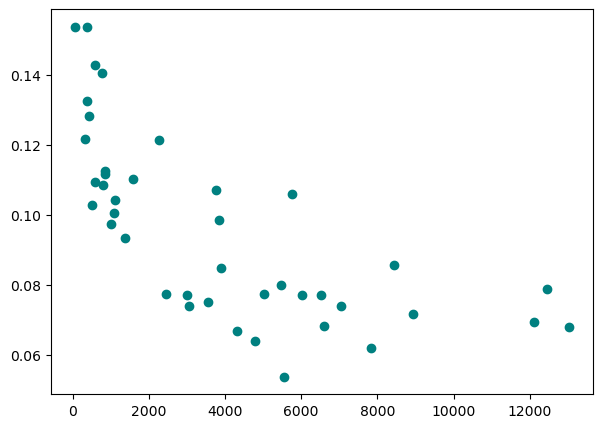

In [4]:
# reload origional  out_df 
out_df = pd.read_csv(r"Z:\projects\Emmett\tracking_analysis\training_tracking\all_extracted_standard_deviations.csv")


mean_stds = []
tstarts = []
for index,t_start in enumerate(out_df.trials_at_start):
    tstarts += [t_start]
    mean_std = np.mean([out_df.std1.values[index],out_df.std2.values[index],out_df.std3.values[index],out_df.std4.values[index]])
    mean_stds += [mean_std/out_df.dist_per_cm[index]]
    
    
fig,ax= plt.subplots(1, 1,figsize=(7, 5))

mean_stds = np.array(mean_stds)[np.argsort(tstarts)]
tstarts = np.array(tstarts)[np.argsort(tstarts)]

ax.plot(tstarts,mean_stds,'o', color = 'teal')
# ax.set_xlim([0,14000])



Text(0.5, 1.0, 'R-squared: 0.73')

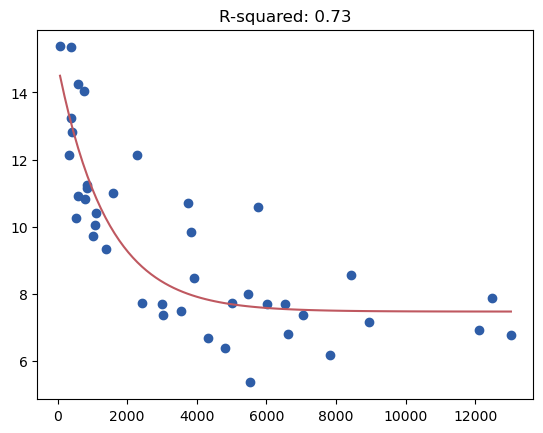

In [5]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the function to fit
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

ydata = mean_stds* 100
xdata = tstarts/tstarts[-1]

# Fit the data
popt, pcov = curve_fit(func, xdata, ydata,p0=[0,0,0], maxfev=5000)

# Calculate R-squared
residuals = ydata - func(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)

# Generate points for the fitted curve
xfit = np.linspace(min(xdata), max(xdata), 100)
yfit = func(xfit, *popt)

# Plot the results
plt.scatter(xdata* tstarts[-1], ydata, color = '#2E5DA7')
plt.plot(xfit * tstarts[-1], yfit, '-', color = '#BF5860')
plt.title(f'R-squared: {r_squared:.2f}')
# plt.show()

# SaveFig('tracking_curve.pdf','D:\\')


Fitted parameters: [7.36389998 9.1724469  7.48010418]
Standard errors: [0.88191607 2.66723051 0.39293587]
t-values: [ 8.34988755  3.43894045 19.0364505 ]
Approximate p-values: [3.982283391934516e-10, 0.0014314384851041861, 0.0]
R-squared: 0.727


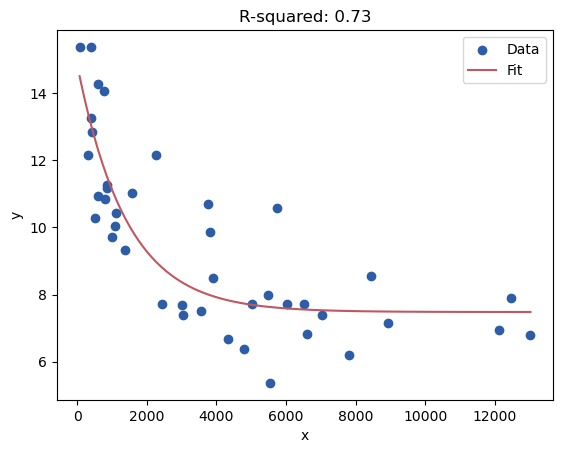

In [7]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import t
import matplotlib.pyplot as plt

# Example data
# xdata = tstarts / tstarts[-1]
# ydata = mean_stds * 100

# Define the model function
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit the curve
popt, pcov = curve_fit(func, xdata, ydata, p0=[0, 0, 0], maxfev=5000)

# Calculate residuals and R-squared
residuals = ydata - func(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)

# Compute parameter standard errors
perr = np.sqrt(np.diag(pcov))

# Compute t-statistics and approximate p-values
dof = max(0, len(ydata) - len(popt))  # degrees of freedom
t_stats = popt / perr
p_values = [2*(1 - t.cdf(np.abs(ti), dof)) for ti in t_stats]

# Print results
print("Fitted parameters:", popt)
print("Standard errors:", perr)
print("t-values:", t_stats)
print("Approximate p-values:", p_values)
print(f"R-squared: {r_squared:.3f}")

# Plot the data and fitted curve
xfit = np.linspace(min(xdata), max(xdata), 100)
yfit = func(xfit, *popt)

plt.scatter(xdata * tstarts[-1], ydata, color='#2E5DA7', label='Data')
plt.plot(xfit * tstarts[-1], yfit, '-', color='#BF5860', label='Fit')
plt.title(f'R-squared: {r_squared:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


In [6]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import f

# Define your model
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit the curve
popt, pcov = curve_fit(func, xdata, ydata, p0=[0, 0, 0], maxfev=5000)

# Residuals for full model
residuals = ydata - func(xdata, *popt)
ss_res = np.sum(residuals**2)

# Residuals for null model (just the mean)
ss_null = np.sum((ydata - np.mean(ydata))**2)

# Degrees of freedom
n = len(ydata)
p = len(popt)  # number of parameters
df_model = p
df_resid = n - p

# F-statistic
f_stat = ((ss_null - ss_res) / df_model) / (ss_res / df_resid)

# Global p-value
p_global = 1 - f.cdf(f_stat, df_model, df_resid)

print(f"Global F-statistic: {f_stat:.3f}")
print(f"Global p-value: {p_global:.3e}")
 

Global F-statistic: 33.667
Global p-value: 8.579e-11


In [1391]:
tracking_df

,animal,session,trials_at_start,tracking_files,back_tracking
0,EJT27,Session20,3904,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
1,EJT27,Session29,6604,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
2,EJT27,Sesssion9,1005,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
3,EJT29,Session10,846,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
4,EJT29,Session19,3006,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
5,EJT29,Session37,8435,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
6,EJT29,Session49,13022,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
7,EJT30,Session37,7822,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
8,EJT30,Session49,12113,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...
9,EJT30,Session9,1584,Z:\projects\Emmett\tracking_analysis\training_...,coords x y likelihood in...


In [ ]:
# plot example data:

In [1706]:
### loop over this and plot out stuff
animal = 9

current_x = tracking_df.back_tracking[animal].interped_x.values
current_y = tracking_df.back_tracking[animal].interped_y.values
port_positions = []
for i in range(5):
    port = port_tracking[animal][i]
    if animal == 2 and i == 1:
        # hacky fix because port 1 was messed up for this tracking
        port_positions += [[np.median(port_tracking[animal][3].interped_x.values),np.median(port_tracking[animal][0].interped_y.values)]]
    else:
        port_positions += [[np.median(port.interped_x),np.median(port.interped_y)]]
    
port_centroids = port_positions
    
coords = []
for ind_,item in enumerate(current_x):
    coords += [[item,current_y[ind_]]]

radius = 45
threshold_breaks = np.zeros(len(coords))
# for each port we care about find where the mouse breaks the distcance threshold
for ind_ in range(0,len(port_centroids)):
    threshold = radius
    target = port_centroids[ind_]
    closest,indicies = closest_points(target, coords, threshold)
    
    threshold_breaks[indicies] = ind_ + 1

# exclude (by labelling with -1) any times the trajetcory goes outside of the port area
half_dist = (port_centroids[0][-1] - port_centroids[4][-1])/2
exclusion_mask = (np.array(current_y) < (port_centroids[0][-1] + half_dist)) * (np.array(current_y) > (port_centroids[4][-1] - half_dist))
exclusion_inds = np.where(exclusion_mask == False)
threshold_breaks[exclusion_inds] = -1

# exclude (by labelling with -1) any times the trajetcory goes outside of the port area
half_dist = (port_centroids[1][0] - port_centroids[0][0])/2
exclusion_mask = (np.array(current_x) > (port_centroids[0][0] - half_dist)) * (np.array(current_x) < (port_centroids[4][0] + half_dist))
exclusion_inds = np.where(exclusion_mask == False)
threshold_breaks[exclusion_inds] = -1

## each of these is a frame so we know the timing between them. ie. one frame is 1/60s 
time_filter = 2 #in s
frame_filter = int(time_filter / (1/60))

In [1724]:
def extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,exclude_port_1,exclude_port_2,exclude_port_3):

    start_ind = []
    end_ind = []


    index = 0
    while index < len(threshold_breaks[:-1]):
        break_ = threshold_breaks[index]
        if break_ == start_port and not threshold_breaks[index+1] ==start_port:
            # find min valin this that is larger than current - ie. next index
            p3_ind = find_next_val(index,threshold_breaks,frame_filter,end_port)
            # ignore any really bad ones that enter othe rports first, the -1 takes care of the excluded trajectories (gets rid of weird noise hwere the DLC tracking jumps outsid eof the task zone)
            if not exclude_port_1 in threshold_breaks[index:p3_ind] and not exclude_port_2 in threshold_breaks[index:p3_ind] and not exclude_port_3 in threshold_breaks[index:p3_ind] and not -1 in threshold_breaks[index:p3_ind]:
                if p3_ind != -1:
                    start_ind += [index-3]
                    end_ind += [p3_ind+3]
                    if not index == (p3_ind - 1):
                        index = p3_ind - 1
                    else:
                        index = p3_ind
                else:
                    index+=1
            else:
                index += 1
        else:
            index +=1

    return start_ind, end_ind

In [1725]:
## each of these is a frame so we know the timing between them. ie. one frame is 1/60s 
time_filter = 1 #in s
frame_filter = int(time_filter / (1/60))


start_port = 5
end_port = 1
# T1_start_ind, T1_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,3,3,4)
T1_start_ind, T1_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,3,4,-1)

start_port = 1
end_port = 4
T2_start_ind, T2_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,-1,3,5)


start_port = 4
end_port = 3
T3_start_ind, T3_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,2,5)

start_port = 3
end_port = 5
T4_start_ind, T4_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,-1,4)


In [1726]:

filtered_split_trajectories_x_positions = []
filtered_split_trajectories_y_positions = []
filtered_split_trajectories_frame_colors = []

segment1 = plot_and_create_xy_segments(T1_start_ind,T1_end_ind,ax,'red')
segment2 = plot_and_create_xy_segments(T2_start_ind,T2_end_ind,ax,'green')
segment3 = plot_and_create_xy_segments(T3_start_ind,T3_end_ind,ax,'blue')
segment4 = plot_and_create_xy_segments(T4_start_ind,T4_end_ind,ax,'grey')

a_curve1 = interpolate_to_longest_and_find_average_curve(segment1)
a_curve2 = interpolate_to_longest_and_find_average_curve(segment2)
a_curve3 = interpolate_to_longest_and_find_average_curve(segment3)
a_curve4 = interpolate_to_longest_and_find_average_curve(segment4)

x = [point[0] for point in a_curve1]
y = [point[1] for point in a_curve1]

x = [point[0] for point in a_curve2]
y = [point[1] for point in a_curve2]

x = [point[0] for point in a_curve3]
y = [point[1] for point in a_curve3]

x = [point[0] for point in a_curve4]
y = [point[1] for point in a_curve4]


100%|████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 9500.49it/s]


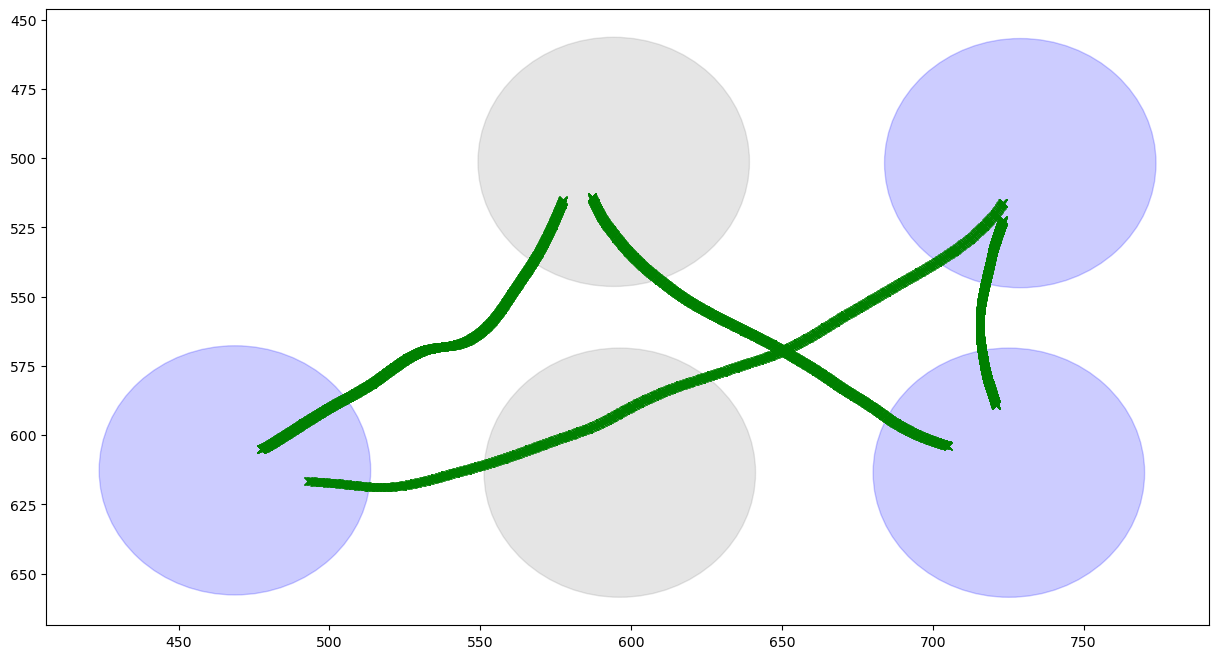

In [1727]:
interpolated_av_curves = []

for a_curve_ in [a_curve1,a_curve2,a_curve3,a_curve4]:

    total_length = total_length_of_curve(a_curve_)
    # chose number of points you want to construct the curve out of - this will only be roughly fitted as the code does a lot of rounding. This cant be smaller than the current length - ifyou do this is will just keep the curve the same (it can only add points)
    num_points = 2000
    # number to multiply the segment length to get the rough breakdown so that we get around 1000 in total 
    segment_warp_factor = num_points/int(total_length) 


    interpolated_av_curve = []
    for i in tqdm(range(len(a_curve_))):
        if i>0:
            st_ = a_curve_[i]
            ed_ = a_curve_[i-1]
            seg_distance = math.dist(st_,ed_)
            num_points_to_add = np.round(seg_distance * segment_warp_factor)
            if num_points_to_add >1:

                seg = [st_] + [ed_]
                x = [point[0] for point in seg]
                y = [point[1] for point in seg]

                M = int(num_points_to_add)
                t = np.linspace(0, len(x), M)
                x_interp = np.interp(t, np.arange(len(x)), x)
                y_interp = np.interp(t, np.arange(len(y)), y)

                interpolated_av_curve += ([[x, y] for x, y in zip(x_interp, y_interp)])


            else:
                interpolated_av_curve += [a_curve_[i]]
                
                
    interpolated_av_curves += [interpolated_av_curve]

            
nrow = 1 
ncol = 1
fig, axs = plt.subplots(nrow, ncol,figsize=(15, 8))

for ind, ax in enumerate(fig.axes):
    
    for index,port_centroid in enumerate(port_centroids):
        ## define rings around important ports: port 5, port2, port 3, port4
        radius = 45
        c = ['blue','grey','blue','grey','blue']
        circle1 = plt.Circle(port_centroid, radius, color=c[index], alpha = 0.2)
        ax.add_patch(circle1)
        
    ax.invert_yaxis()

    for interpolated_av_curve in interpolated_av_curves:
        x = [point[0] for point in interpolated_av_curve]
        y = [point[1] for point in interpolated_av_curve]
        ax.plot(x, y, 'x',color = 'green')
    
    
median_dists1=[]
std_dists1 = []
for i in range(len(segment1)):
    index,dist = closest_point(segment1[i],interpolated_av_curves[0])
    median_dists1 += [np.median(dist)]
    std_dists1 += [np.std(dist)]


median_dists2=[]
std_dists2 = []
for i in range(len(segment2)):
    index,dist = closest_point(segment2[i],interpolated_av_curves[1])
    median_dists2 += [np.median(dist)]
    std_dists2 += [np.std(dist)]


median_dists3=[]
std_dists3 = []
for i in range(len(segment3)):
    index,dist = closest_point(segment3[i],interpolated_av_curves[2])
    median_dists3 += [np.median(dist)]
    std_dists3 += [np.std(dist)]


median_dists4=[]
std_dists4 = []
for i in range(len(segment4)):
    index,dist = closest_point(segment4[i],interpolated_av_curves[3])
    median_dists4 += [np.median(dist)]
    std_dists4 += [np.std(dist)]



44
48
77
118


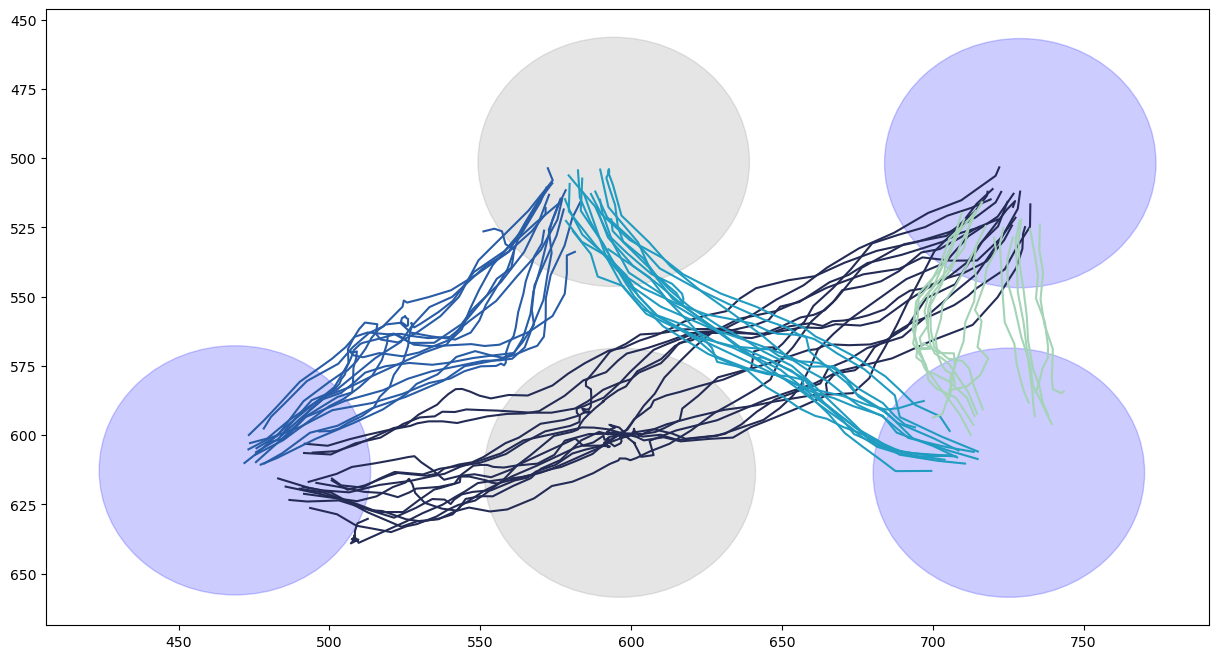

In [1760]:
## plot 
import random


def plot_mean_like_curves(std_dists4,segment4,COLOR):

    plotable_indexes = []
    mean_std = np.mean(std_dists4)
    for index,item in enumerate(std_dists4):
        if item < mean_std + (mean_std* 0.2):
            if item > mean_std - (mean_std* 0.2):
                plotable_indexes += [index]
                
    print(len(plotable_indexes))
    

    plotable_indexes = random.sample(plotable_indexes, 15)

    for index in plotable_indexes:
        curve = segment4[index]
        x = [point[0] for point in curve]
        y = [point[1] for point in curve]
        ax.plot(x, y, '-',color = COLOR)
        
    return plotable_indexes

            
nrow = 1 
ncol = 1
fig, axs = plt.subplots(nrow, ncol,figsize=(15, 8))

for ind, ax in enumerate(fig.axes):
    
    for index,port_centroid in enumerate(port_centroids):
        ## define rings around important ports: port 5, port2, port 3, port
        radius = 45
        c = ['blue','grey','blue','grey','blue']
        circle1 = plt.Circle(port_centroid, radius, color=c[index], alpha = 0.2)
        ax.add_patch(circle1)
        
    ax.invert_yaxis()
    
    plotable_indexes1b = plot_mean_like_curves(std_dists1,segment1,'#242C55')
    plotable_indexes2b = plot_mean_like_curves(std_dists2,segment2,'#285CA6')
    plotable_indexes3b = plot_mean_like_curves(std_dists3,segment3,'#219CC1')
    plotable_indexes4b = plot_mean_like_curves(std_dists4,segment4,'#A4D3B6')
    
# plt.show()

        
# SaveFig('tracking_curve_example.pdf','D:\\')

In [1757]:
def plot_mean_like_curves(std_dists4,segment4,COLOR,plotable_indexes):
    for index in plotable_indexes:
        curve = segment4[index]
        x = [point[0] for point in curve]
        y = [point[1] for point in curve]
        ax.plot(x, y, '-',color = COLOR)


nrow = 1 
ncol = 1
fig, axs = plt.subplots(nrow, ncol,figsize=(15, 8))

for ind, ax in enumerate(fig.axes):
    
    for index,port_centroid in enumerate(port_centroids):
        ## define rings around important ports: port 5, port2, port 3, port4
        radius = 45
        c = ['blue','grey','blue','grey','blue']
        circle1 = plt.Circle(port_centroid, radius, color=c[index], alpha = 0.2)
        ax.add_patch(circle1)
        
    ax.invert_yaxis()
    
    plot_mean_like_curves(std_dists1,segment1,'#242C55',plotable_indexes1)
    plot_mean_like_curves(std_dists2,segment2,'#285CA6',plotable_indexes2)
    plot_mean_like_curves(std_dists3,segment3,'#219CC1',plotable_indexes3)
    plot_mean_like_curves(std_dists4,segment4,'#A4D3B6',plotable_indexes4)
    
SaveFig('tracking_curve_example.pdf','D:\\')

In [1534]:
## calculate relative distance:
dist_per_cm = []
for ind in range(len(tracking_df)):

    ### loop over this and plot out stuff
    animal = ind

    current_x = tracking_df.back_tracking[animal].interped_x.values
    current_y = tracking_df.back_tracking[animal].interped_y.values
    port_positions = []
    for i in range(5):
        port = port_tracking[animal][i]
        if animal == 2 and i == 1:
            # hacky fix because port 1 was messed up for this tracking
            port_positions += [[np.median(port_tracking[animal][3].interped_x.values),np.median(port_tracking[animal][0].interped_y.values)]]
        else:
            port_positions += [[np.median(port.interped_x),np.median(port.interped_y)]]

    port_centroids = port_positions
                   
    distance = math.dist(port_centroids[0],port_centroids[1])
    dist_per_cm += [distance / 3]

In [1535]:
dist_per_cm

[41.12642180061943,
 56.4760317975944,
 37.52215576171875,
 39.097619226386094,
 41.70220428302108,
 40.33047512463239,
 40.5896931766815,
 40.38065250023026,
 40.700956067248406,
 42.534299975437314,
 41.319657947798326,
 39.03300011579675,
 41.333034368328605,
 38.97813500978342,
 41.39339924395311,
 38.81018743331102,
 38.74579556456912,
 39.58000578236949,
 38.904293763622675,
 41.158791438847146,
 38.43078762374899,
 40.71918239042805,
 38.50212049167015,
 38.41949680292644,
 38.796038953498105,
 39.38608054094711,
 0.0,
 38.67717174117553,
 39.41390447623756,
 39.598898800036956,
 39.21276839485328,
 39.098876607348,
 40.31000654534528,
 38.296901959713914,
 38.982295587343245,
 38.70396354080088,
 41.29345067289447,
 38.68115464101388,
 41.28840426880145,
 38.52151409464171,
 41.37551921527009,
 41.20178780357707,
 41.405011275095355,
 41.50659185494565,
 38.805129732802634,
 38.1440145942507]

In [1526]:
distance

127.60289992631195

<ErrorbarContainer object of 3 artists>

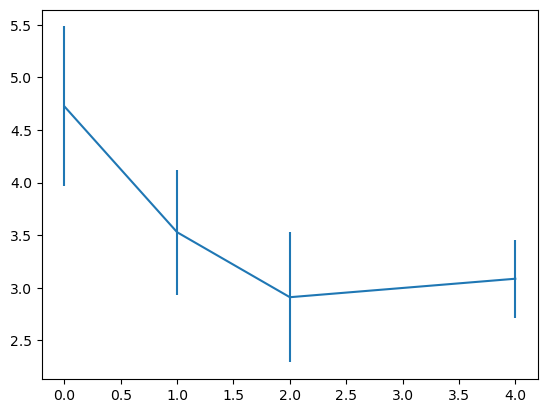

In [1303]:
grouped_means = []
grouped_stds = []

mask = (tstarts >= 0) * (tstarts <= 2000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 2000) * (tstarts <= 4000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 4000) * (tstarts <= 6000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 6000) 
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

plt.errorbar(np.array([0,1,2,4]),grouped_means,yerr=grouped_stds)

array([   69.        ,   199.83838384,   330.67676768,   461.51515152,
         592.35353535,   723.19191919,   854.03030303,   984.86868687,
        1115.70707071,  1246.54545455,  1377.38383838,  1508.22222222,
        1639.06060606,  1769.8989899 ,  1900.73737374,  2031.57575758,
        2162.41414141,  2293.25252525,  2424.09090909,  2554.92929293,
        2685.76767677,  2816.60606061,  2947.44444444,  3078.28282828,
        3209.12121212,  3339.95959596,  3470.7979798 ,  3601.63636364,
        3732.47474747,  3863.31313131,  3994.15151515,  4124.98989899,
        4255.82828283,  4386.66666667,  4517.50505051,  4648.34343434,
        4779.18181818,  4910.02020202,  5040.85858586,  5171.6969697 ,
        5302.53535354,  5433.37373737,  5564.21212121,  5695.05050505,
        5825.88888889,  5956.72727273,  6087.56565657,  6218.4040404 ,
        6349.24242424,  6480.08080808,  6610.91919192,  6741.75757576,
        6872.5959596 ,  7003.43434343,  7134.27272727,  7265.11111111,
      

In [1316]:
xfit

array([   69.        ,   199.83838384,   330.67676768,   461.51515152,
         592.35353535,   723.19191919,   854.03030303,   984.86868687,
        1115.70707071,  1246.54545455,  1377.38383838,  1508.22222222,
        1639.06060606,  1769.8989899 ,  1900.73737374,  2031.57575758,
        2162.41414141,  2293.25252525,  2424.09090909,  2554.92929293,
        2685.76767677,  2816.60606061,  2947.44444444,  3078.28282828,
        3209.12121212,  3339.95959596,  3470.7979798 ,  3601.63636364,
        3732.47474747,  3863.31313131,  3994.15151515,  4124.98989899,
        4255.82828283,  4386.66666667,  4517.50505051,  4648.34343434,
        4779.18181818,  4910.02020202,  5040.85858586,  5171.6969697 ,
        5302.53535354,  5433.37373737,  5564.21212121,  5695.05050505,
        5825.88888889,  5956.72727273,  6087.56565657,  6218.4040404 ,
        6349.24242424,  6480.08080808,  6610.91919192,  6741.75757576,
        6872.5959596 ,  7003.43434343,  7134.27272727,  7265.11111111,
      

In [1288]:
xdata = np.array([0,1,2,3,4,5,6,10])
ydata = grouped_means

<ErrorbarContainer object of 3 artists>

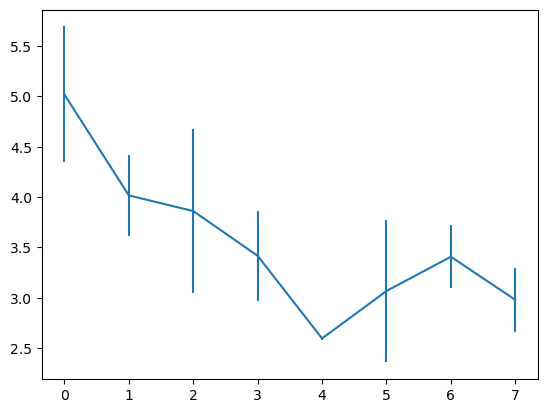

In [1279]:
grouped_means = []
grouped_stds = []

mask = tstarts <= 1000
np.mean(mean_stds[mask])
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 1000) * (tstarts <= 2000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 2000) * (tstarts <= 3000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 3000) * (tstarts <= 4000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 4000) * (tstarts <= 5000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 5000) * (tstarts <= 6000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 6000) * (tstarts <= 7000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]

mask = (tstarts >= 7000) * (tstarts <= 13000)
grouped_means += [np.mean(mean_stds[mask])]
grouped_stds += [np.std(mean_stds[mask])]




<ErrorbarContainer object of 3 artists>

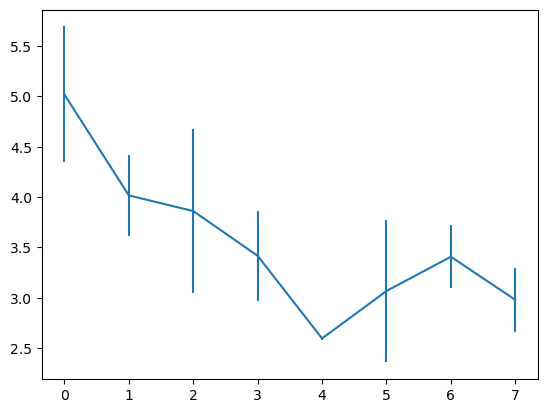

In [1273]:
len(grouped_stds)

9

In [1267]:
grouped_stds

[0.6747391443496462,
 0.6747391443496462,
 0.4016685924958494,
 0.8150605905000001,
 0.44421709392604386,
 0.018506045999999943,
 0.7099006286295181,
 0.3141160500872619,
 0.3180706338620408]

In [1249]:
mask = (tstarts >= 1000) * (tstarts <= 2000)
np.mean(mean_stds[mask])

4.0163911601999995

In [1251]:
mask = (tstarts >= 2000) * (tstarts <= 3000)
np.mean(mean_stds[mask])

3.8608179705000003

In [1252]:
mask = (tstarts >= 3000) * (tstarts <= 4000)
np.mean(mean_stds[mask])

3.4165962022083334

In [1253]:
mask = (tstarts >= 4000) * (tstarts <= 5000)
np.mean(mean_stds[mask])

2.595528677

0.7099006286295181

In [770]:
from scipy.spatial import KDTree

def closest_point(line1, line2):
    tree = KDTree(line2)
    dist, index = tree.query(line1)
    return index, dist

# work out rolling closest point to av line
closest_indicies = []

# extra piece is added onto the end to try and stop the end bin getting lumped with all of the leftover data  
extra_piece =50

# for i in range(len(segment1)):
    
#     segment1[i]
    

    
    
    
    
    
#     # crappy filter added in here to get around weird bug that sometimes occurs
#     if split_trajects_port_indicies[i][-1] == split_trajects_port_indicies[i][-2]:
#         print('bug')
#         split_trajects_port_indicies[i][-2] = split_trajects_port_indicies[i][-1] - 2
    
#     #find closest point from start to port to port 2
#     traject = combined_xy_trajectories[i][0:split_trajects_port_indicies[i][1]]
#     end_segment = av_curve_closestport_indicies[0][1]
#     index, dist = closest_point(traject, interpolated_av_curve[0:end_segment+extra_piece])
#     closest_inds = list(index)

#     #find closest point from port 2 to port 4
#     traject = combined_xy_trajectories[i][split_trajects_port_indicies[i][1]:split_trajects_port_indicies[i][3]]
#     start_segment = av_curve_closestport_indicies[0][1]
#     end_segment = av_curve_closestport_indicies[0][3]
#     index, dist = closest_point(traject, interpolated_av_curve[start_segment-extra_piece:end_segment])
#     #indicies are calcuated reltive to segment so add on previous segment inds
#     closest_inds += list(index+av_curve_closestport_indicies[0][1])
    
#     #find closest point from port 4 to port 5
#     traject = combined_xy_trajectories[i][split_trajects_port_indicies[i][3]:split_trajects_port_indicies[i][4]]
#     start_segment = av_curve_closestport_indicies[0][3]
#     end_segment = av_curve_closestport_indicies[0][4]
#     index, dist = closest_point(traject, interpolated_av_curve[start_segment-10:end_segment+extra_piece])
#     closest_inds += list(index+av_curve_closestport_indicies[0][3])

#     #find closest point from port 5 to the rest
#     traject = combined_xy_trajectories[i][split_trajects_port_indicies[i][4]::]
#     start_segment = av_curve_closestport_indicies[0][4]
#     index, dist = closest_point(traject, interpolated_av_curve[start_segment-extra_piece::])
#     closest_inds += list(index+av_curve_closestport_indicies[0][4])


#     closest_indicies += [closest_inds]

In [776]:
tree = KDTree(
dist, index = tree.query()

In [778]:
segment1[i]

[(676.4905395507812, 330.4375915527344),
 (671.9281005859375, 323.3993225097656),
 (668.6251220703125, 318.6685791015625),
 (666.109130859375, 316.12890625),
 (665.6063842773438, 311.50738525390625),
 (661.0974731445312, 309.7256774902344),
 (654.9497680664062, 310.8987731933594),
 (648.4568481445312, 316.0658874511719),
 (642.6786499023438, 315.6853942871094),
 (638.0065307617188, 313.7701416015625),
 (632.2044067382812, 310.538818359375),
 (628.5202026367188, 310.6416320800781),
 (628.0908203125, 311.0666198730469),
 (627.707275390625, 312.25018310546875),
 (627.274169921875, 315.3291320800781),
 (623.5635986328125, 321.79290771484375),
 (616.2440185546875, 323.00421142578125),
 (609.3320922851562, 326.40948486328125),
 (604.8153686523438, 327.5069885253906),
 (596.318603515625, 329.6658935546875),
 (582.1055297851562, 330.0140075683594),
 (572.9478759765625, 331.123291015625),
 (567.4728393554688, 330.63232421875),
 (564.89697265625, 330.2999267578125),
 (563.0371704101562, 330.5036

In [777]:
tree

In [772]:
closest_point(segment1[i],interpolated_av_curves[0])

(array([ 113,  113,  112,  109,    6,  106,  191,  285,  326,  380,  362,
         417,  417,  417,  406,  395,  483,  520,  497,  529,  596,  652,
         745,  781,  775,  773,  771,  817,  815,  816,  816,  817,  817,
         777,  773,  779,  775,  812,  881,  880,  845,  803,  841,  907,
         965, 1026, 1107, 1123, 1148, 1141, 1167, 1206, 1199, 1199, 1301,
        1401, 1576, 1631, 1631, 1702, 1726, 1807, 1892, 1951, 2009],
       dtype=int64),
 array([11.51244246, 19.90008429, 25.66444656, 29.1582118 , 32.9235292 ,
        37.25158413, 39.07715199, 36.76325696, 38.90664924, 42.1408902 ,
        47.12677318, 48.31217603, 48.08342383, 47.14780018, 44.50298866,
        40.18055336, 42.6269579 , 43.56037516, 45.33419742, 49.08288999,
        58.76032047, 64.54612802, 68.31425407, 70.10390053, 71.00858271,
        71.65437555, 72.91969127, 72.51063642, 72.4993131 , 72.51793888,
        71.71424615, 66.73446578, 61.74230131, 56.37625751, 50.86885527,
        43.95827684, 37.82235

In [734]:
interpolate_to_longest_and_find_average_curve(segment1)

[[693.3283374288808, 693.3283374288808],
 [692.5612288972605, 692.5612288972605],
 [691.6196076683376, 691.6196076683376],
 [689.9696301004161, 689.9696301004161],
 [687.6492955415146, 687.6492955415146],
 [684.0360929758652, 684.0360929758652],
 [679.6001275850379, 679.6001275850379],
 [674.5243886957998, 674.5243886957998],
 [668.5466848705125, 668.5466848705125],
 [662.6690137956454, 662.6690137956454],
 [657.0230153104534, 657.0230153104534],
 [651.6438044309616, 651.6438044309616],
 [646.714977695631, 646.714977695631],
 [642.3173635544985, 642.3173635544985],
 [638.3097574316937, 638.3097574316937],
 [634.6093204878379, 634.6093204878379],
 [631.0843211519546, 631.0843211519546],
 [627.9540980753691, 627.9540980753691],
 [625.1286277819371, 625.1286277819371],
 [622.3549979146322, 622.3549979146322],
 [619.4544310367334, 619.4544310367334],
 [616.48179529189, 616.48179529189],
 [613.180062966158, 613.180062966158],
 [609.6971752767079, 609.6971752767079],
 [606.1576910383668, 606

In [ ]:
segments_1 = []
segments_2 = []
segments_3 = []
segments_4 = []

for ind,traject_ in enumerate(combined_xy_trajectories):
    segments_1 += current_x[T1_start_ind[i]:T1_end_ind[i]],current_y[T1_start_ind[i]:T1_end_ind[i]]
    segments_2 += [traject_[split_trajects_port_indicies[ind][0]:split_trajects_port_indicies[ind][1]]]
    segments_3 += [traject_[split_trajects_port_indicies[ind][1]:split_trajects_port_indicies[ind][2]]]
    segments_4 += [traject_[split_trajects_port_indicies[ind][2]:split_trajects_port_indicies[ind][3]]]


segments = [segments_1] + [segments_2] + [segments_3] + [segments_4] + [segments_5]

In [718]:
segments_1 = []
for i in range(len(T1_start_ind)):
    
    
    for ind_,item in enumerate(T1_start_ind[i]):
        traject_coords += [[item,filtered_split_trajectories_y_positions[i][ind_]]]    

    segments_1 += [current_x[T1_start_ind[i]:T1_end_ind[i]],current_y[T1_start_ind[i]:T1_end_ind[i]]]

In [719]:
current_x[T1_start_ind[i]:T1_end_ind[i]]

array([693.54547119, 692.34906006, 688.91235352, 683.93066406,
       672.30804443, 657.55957031, 648.16137695, 642.55377197,
       626.81671143, 619.13256836, 606.48181152, 606.48181152,
       606.68629964, 606.89078776, 607.09527588, 609.84912109,
       612.2878418 , 608.57537842, 605.7166748 , 605.7166748 ,
       601.29124173, 596.86580866, 592.44037559, 588.01494252,
       583.58950944, 579.16407637, 574.7386433 , 570.31321023,
       565.88777716, 561.46234408, 557.03691101, 552.61147794,
       548.18604487, 543.76061179, 539.33517872, 534.90974565,
       530.48431258, 526.05887951, 521.63344643, 517.20801336,
       512.78258029, 508.35714722, 502.07287598, 502.07287598,
       491.11830139, 480.16372681, 470.79949951, 461.40814209,
       451.06509399])

In [700]:
current_x[T1_start_ind[i]:T1_end_ind[i]]

current_y[T1_start_ind[i]:T1_end_ind[i]]

IndexError: list index out of range

IndexError: invalid index to scalar variable.

In [712]:
# Find the length of the longest curve
max_length = max([len(curve) for curve in segments_1])

# Interpolate each curve to the length of the longest curve
interpolated_curves = []
for curve in segments_1:
    if len(curve) > 0:
        x = [point[0] for point in curve]
        y = [point[1] for point in curve]

        # find lots of points on the piecewise linear curve defined by x and y
        M = max_length
        t = np.linspace(0, len(x), M)
        x_interp = np.interp(t, np.arange(len(x)), x)
        y_interp = np.interp(t, np.arange(len(y)), y)

        interpolated_curves.append([[x, y] for x, y in zip(x_interp, y_interp)])

# # Average the x and y coordinates of all the interpolated curves
average_curve = []
for i in range(max_length):
    x_sum = 0
    y_sum = 0
    for curve in interpolated_curves:
        x_sum += curve[i][0]
        y_sum += curve[i][1]
    average_curve.append([x_sum / len(interpolated_curves), y_sum / len(interpolated_curves)])

IndexError: invalid index to scalar variable.

In [714]:
curve

array([676.49053955, 671.92810059, 668.62512207, 666.10913086,
       665.60638428, 661.09747314, 654.94976807, 648.45684814,
       642.6786499 , 638.00653076, 632.20440674, 628.52020264,
       628.09082031, 627.70727539, 627.27416992, 623.56359863,
       616.24401855, 609.33209229, 604.81536865, 596.31860352,
       582.10552979, 572.94787598, 567.47283936, 564.89697266,
       563.03717041, 562.04064941, 561.01812744, 560.85449219,
       560.44488525, 560.67193604, 560.94128418, 564.01171875,
       566.95483398, 571.89660645, 574.11236572, 579.37164307,
       582.13000488, 582.54229736, 583.07897949, 586.83856201,
       592.92926025, 598.09942627, 597.74145508, 593.02355957,
       589.19696045, 583.6116333 , 578.63452148, 574.27612305,
       568.29199219, 565.2310791 , 561.44573975, 559.88336182,
       559.99511719, 559.99511719, 545.01507568, 530.03503418,
       515.05499268, 506.66540527, 506.66540527, 497.17048645,
       487.67556763, 477.49212646, 469.57870483, 456.33

In [681]:
port_centroids[0][-1] + half_dist

660.9368190904604

In [421]:
### times when the mouse enters port 7 then enters port 1
# 1 to 6
# 6 to 3
# 3 to 7










# # #find times when the mouse does the sequence:

# start_ind = []
# end_ind = []
# P5_in_ind = []
# index = 0
# while index < len(threshold_breaks[:-1]):
# # for index,break_ in enumerate(threshold_breaks[:-1]):
#     break_ = threshold_breaks[index]
#     if break_ == 5 and not threshold_breaks[index+1] ==5:
#         # find min valin this that is larger than current - ie. next index
#         p2_ind = find_next_val(index,threshold_breaks,frame_filter,2)
#         if p2_ind != -1:
#             # find min valin this that is larger than current - ie. next index
#             p3_ind = find_next_val(p2_ind,threshold_breaks,frame_filter,3)
#             if p3_ind != -1:
#                 # find min valin this that is larger than current - ie. next index
#                 p4_ind = find_next_val(p3_ind,threshold_breaks,frame_filter,4)
#                 if p4_ind != -1:
#                     # find min valin this that is larger than current - ie. next index
#                     p5_ind = find_next_val(p4_ind,threshold_breaks,frame_filter,5)
#                     if p5_ind != -1:
#                         p5_out_ind = find_next_val(p5_ind,threshold_breaks,frame_filter,0)
#                         if p5_out_ind != -1:
#                             start_ind += [index]
#                             end_ind += [p5_out_ind]
#                             index = p5_out_ind - 1
#                         else: 
#                             index +=1
#                     else: 
#                         index += 1
#                 else: 
#                     index += 1
#             else: 
#                 index += 1
#         else: 
#             index += 1
#     else: 
#         index += 1

In [ ]:

## find times it comes within ble circles (distance is less than radius)
## find times it does so in the order 5,2,3,4,5 with less than 2s between 

def closest_points(target, points, threshold):
    import math
    closest = []
    indicies = []
    for index,point in enumerate(points):
        distance = math.dist(target,point)
        if distance <= threshold:
            closest.append(point)
            indicies.append(index)
    return closest,indicies

def find_next_val(index,threshold_breaks,frame_filter,port_type):
    p2_indicies = np.where(threshold_breaks == port_type)[0]
    try:
        p2_min_val = min(i for i in p2_indicies if i > index)
        distance = p2_min_val - index
    except:
        distance = 9999999
    if distance<frame_filter:
        return p2_min_val
    else:
        return -1

    
coords = []
for ind_,item in enumerate(all_x_position):
    coords += [[item,all_y_position[ind_]]]
    
threshold_breaks = np.zeros(len(coords))
# for each port we care about find where the mouse breaks the distcance threshold
for ind_ in range(1,len(port_centroids)):
    threshold = radius
    target = port_centroids[ind_]
    closest,indicies = closest_points(target, coords, threshold)
    threshold_breaks[indicies] = ind_ + 1





In [269]:
tracking_df

,animal,label,tracking_files,back_tracking
0,EJT155,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...,coords x y likelihood in...
1,EJT155,after,Z:\projects\Emmett\tracking_analysis\lesion_tr...,coords x y likelihood in...
2,EJT156,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...,coords x y likelihood int...
3,EJT156,after,Z:\projects\Emmett\tracking_analysis\lesion_tr...,coords x y likelihood in...
4,EJT159,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...,coords x y likelihood in...


In [278]:
port = port_tracking[0][0]

In [280]:
np.mean(port.x)

452.0868804610352

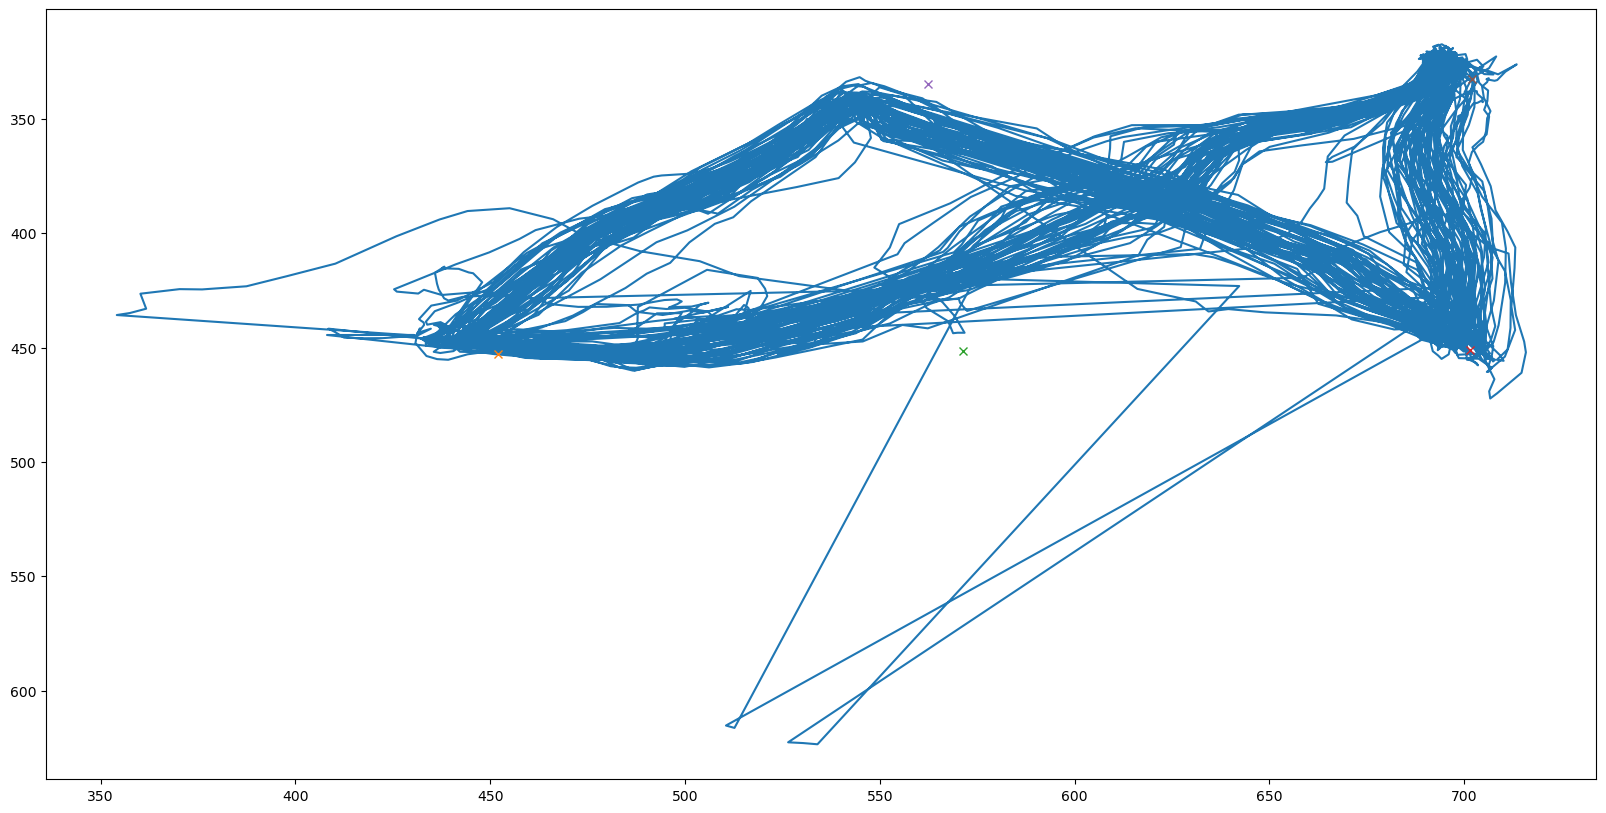

In [325]:

fig,ax = plt.subplots(1, 1,figsize=(20, 10))


current_df = tracking_df.back_tracking[0]
ax.plot(current_df.x[40000:50000],current_df.y[40000:50000])

for i in range(5):
    port = port_tracking[0][i]
    ax.plot(np.mean(port.x),np.mean(port.y),'x')
    
ax.invert_yaxis()

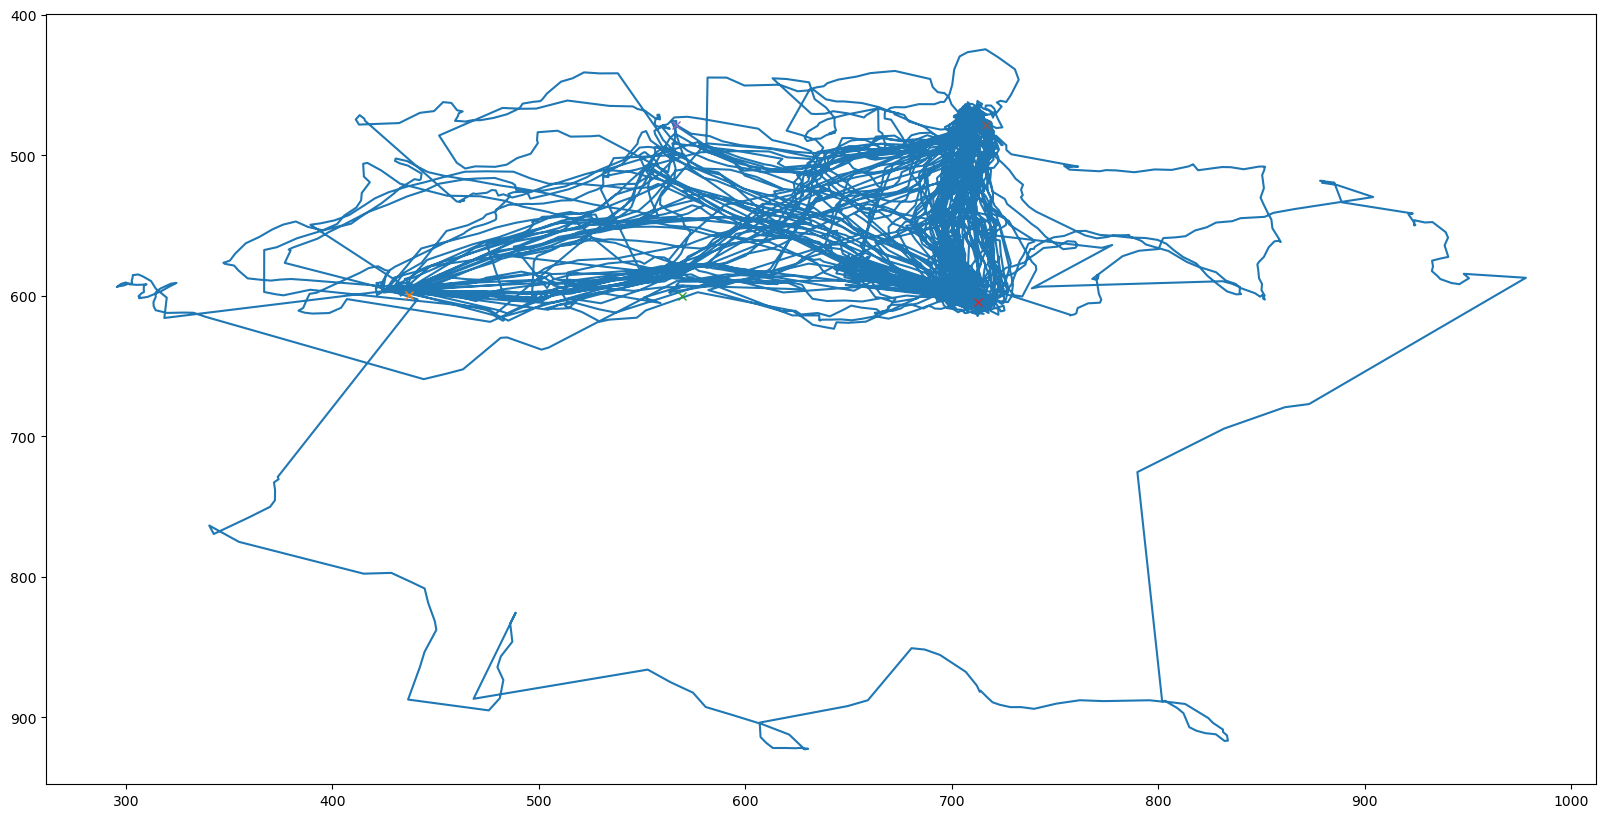

In [292]:

fig,ax = plt.subplots(1, 1,figsize=(20, 10))


current_df = tracking_df.back_tracking[1]
ax.plot(current_df.x[40000:50000],current_df.y[40000:50000])

for i in range(5):
    port = port_tracking[1][i]
    ax.plot(np.mean(port.x),np.mean(port.y),'x')
    
ax.invert_yaxis()

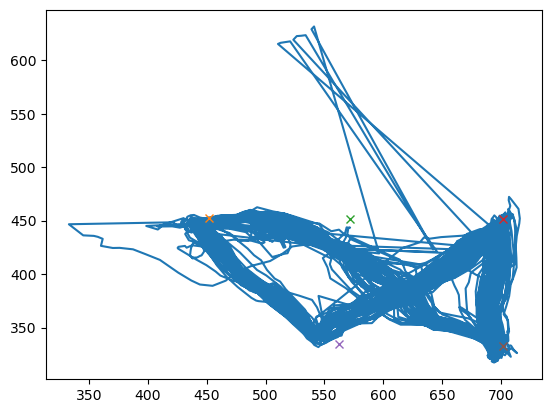

In [223]:
port = port_tracking[0][0]

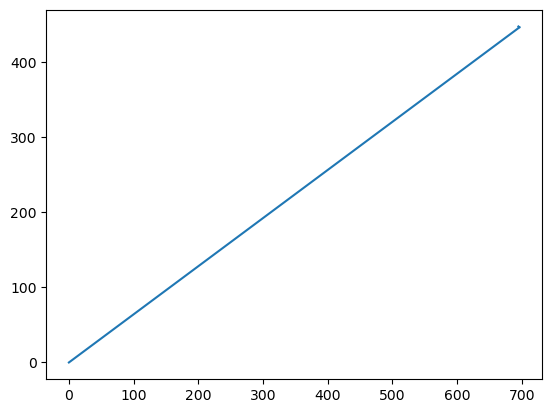

In [224]:
plt.plot(port.x,port.y)

In [230]:
back_file= pd.read_hdf(tracking_file)  
scorer = back_file.columns.tolist()[0][0]
body_part = back_file[scorer]

In [187]:
tracking_df['port_tracking'] = port_tracking


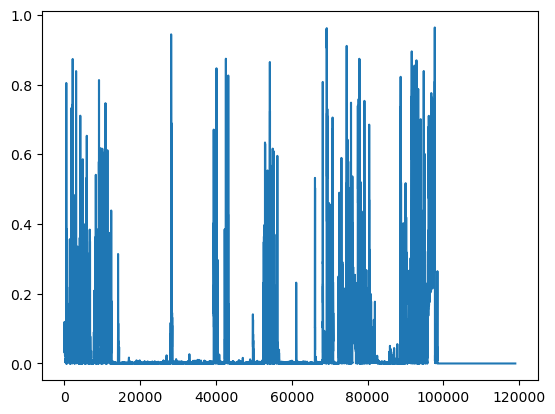

In [239]:
plt.plot(body_part.port2.likelihood)

In [176]:
len(port_tracking)

36

In [173]:
tracking_df.tracking_files[1]

'Z:\\projects\\Emmett\\tracking_analysis\\lesion_tracking\\tracking\\EJT155\\011221\\Camera12021-12-01T10_00_25DLC_resnet50_task-tracking_backviewApr6shuffle1_800000.h5'

In [166]:
len(back_tracking)

6

In [160]:
[[back_p1,back_p2,back_p3,back_p4,back_p5]]

[[coords    x    y  likelihood  interped_x  interped_y
  0       0.0  0.0    0.000150         0.0         0.0
  1       0.0  0.0    0.000166         0.0         0.0
  2       0.0  0.0    0.000171         0.0         0.0
  3       0.0  0.0    0.000137         0.0         0.0
  4       0.0  0.0    0.000130         0.0         0.0
  ...     ...  ...         ...         ...         ...
  163939  0.0  0.0    0.000125         0.0         0.0
  163940  0.0  0.0    0.000146         0.0         0.0
  163941  0.0  0.0    0.000131         0.0         0.0
  163942  0.0  0.0    0.000115         0.0         0.0
  163943  0.0  0.0    0.000100         0.0         0.0
  
  [163944 rows x 5 columns],
  coords           x        y  likelihood  interped_x  interped_y
  0       437.089294  452.237    0.000177  437.089294     452.237
  1       437.089294  452.237    0.000154  437.089294     452.237
  2       437.089294  452.237    0.000159  437.089294     452.237
  3       437.089294  452.237    0.000131  4

In [113]:
Path(tracking_file)

WindowsPath('Z:/projects/Emmett/tracking_analysis/lesion_tracking/tracking/EJT155/011221/Camera12021-12-01T10_00_25DLC_resnet50_port-tracking_back_viewMay2shuffle1_500000.h5')

In [79]:
tracking_file

'Z:\\projects\\Emmett\\tracking_analysis\\lesion_tracking\\tracking\\\\EJT159\\021221\\Camera12021-12-03T09_49_20DLC_resnet50_task-tracking_backviewApr6shuffle1_800000_meta.pickle'

In [76]:
tracking_df

,animal,label,tracking_files
0,EJT155,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...
1,EJT155,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...
2,EJT155,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...
3,EJT155,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...
4,EJT155,after,Z:\projects\Emmett\tracking_analysis\lesion_tr...
5,EJT155,after,Z:\projects\Emmett\tracking_analysis\lesion_tr...
6,EJT155,after,Z:\projects\Emmett\tracking_analysis\lesion_tr...
7,EJT155,after,Z:\projects\Emmett\tracking_analysis\lesion_tr...
8,EJT156,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...
9,EJT156,before,Z:\projects\Emmett\tracking_analysis\lesion_tr...


In [55]:
os.listdir(current_tracking_path)

[]

In [11]:
folders

['030521', '280421']

'Z:\\projects\\Emmett\\tracking_analysis\\lesion_tracking\\tracking\\\\EJT85'

In [14]:
os.path.join(path + animal,folder) 

'Z:\\projects\\Emmett\\tracking_analysis\\lesion_tracking\\tracking\\\\EJT85\\280421'